In [199]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [200]:
df = pd.read_csv("Online Retail.csv", encoding="ISO-8859-1")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [201]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [202]:
df = df.dropna(subset=["CustomerID"])
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]
df = df[df["Quantity"] > 0]

In [203]:
print(df.isna().sum())
print(df.shape)


InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64
(397924, 8)


In [204]:
df['Description'].unique()

array(['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN',
       'CREAM CUPID HEARTS COAT HANGER', ...,
       'PINK CRYSTAL SKULL PHONE CHARM',
       'CREAM HANGING HEART T-LIGHT HOLDER',
       'PAPER CRAFT , LITTLE BIRDIE'], dtype=object)

In [205]:
df['Description'].value_counts()


,count
Description,
WHITE HANGING HEART T-LIGHT HOLDER,2028
REGENCY CAKESTAND 3 TIER,1724
JUMBO BAG RED RETROSPOT,1618
ASSORTED COLOUR BIRD ORNAMENT,1408
PARTY BUNTING,1397
...,...
CLASSIC DIAMANTE NECKLACE JET,1
DIAMANTE NECKLACE BLACK,1
ANT SILVER TURQUOISE BOUDICCA RING,1


In [206]:
df['CustomerID'].value_counts()

,count
CustomerID,
17841.0,7847
14911.0,5677
14096.0,5111
12748.0,4596
14606.0,2700
...,...
17986.0,1
16737.0,1
13017.0,1


In [207]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [208]:
le=LabelEncoder()
df['Description']=le.fit_transform(df['Description'])
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,3698,6,01-12-2010 08:26,2.55,17850.0,United Kingdom
1,536365,71053,3706,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,858,8,01-12-2010 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,1804,6,01-12-2010 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,2763,6,01-12-2010 08:26,3.39,17850.0,United Kingdom


In [209]:
df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    dayfirst=True,
    errors="coerce"
)

In [210]:
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

In [211]:
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "nunique",
    "TotalPrice": "sum"
})
rfm.head()

,InvoiceDate,InvoiceNo,TotalPrice
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [212]:
rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [213]:
print(rfm.head())
rfm.describe()

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2053.793018
std,100.009747,7.705493,8988.248381
min,1.000000,1.000000,0.000000
25%,18.000000,1.000000,307.245000
50%,51.000000,2.000000,674.450000
75%,142.000000,5.000000,1661.640000
max,374.000000,210.000000,280206.020000


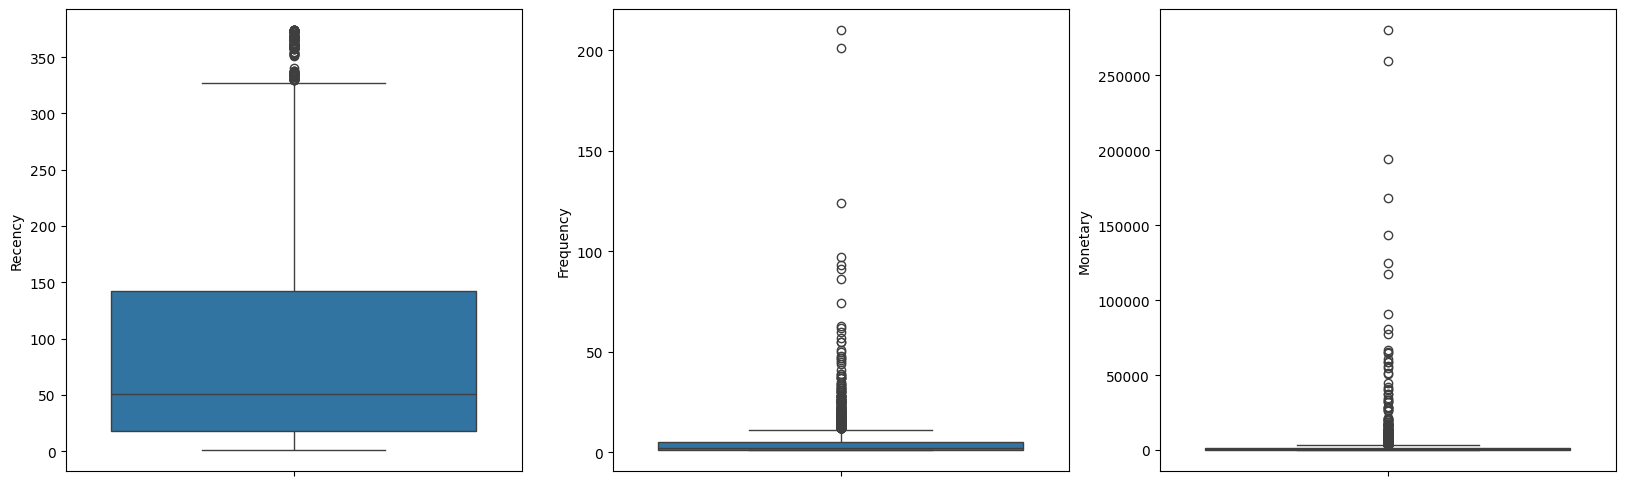

In [214]:
import seaborn as sns

plt.figure(figsize=(20,6))

plt.subplot(1,3,1)
sns.boxplot(y=rfm['Recency'])

plt.subplot(1,3,2)
sns.boxplot(y=rfm['Frequency'])

plt.subplot(1,3,3)
sns.boxplot(y=rfm['Monetary'])

plt.show()

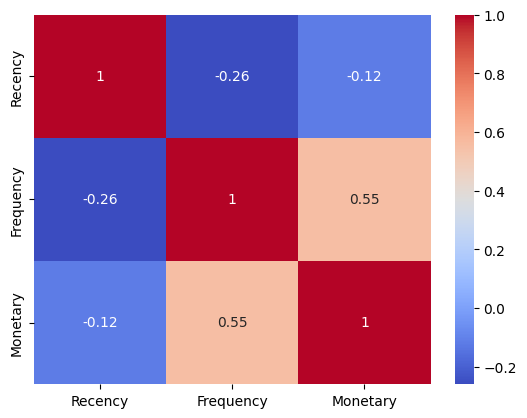

In [215]:
sns.heatmap(rfm.corr(), annot=True, cmap="coolwarm")
plt.show()

In [216]:
Q1 = rfm.quantile(0.25)
Q3 = rfm.quantile(0.75)
IQR = Q3 - Q1

rfm_clean = rfm[~((rfm < (Q1 - 1.5 * IQR)) |
                  (rfm > (Q3 + 1.5 * IQR))).any(axis=1)]

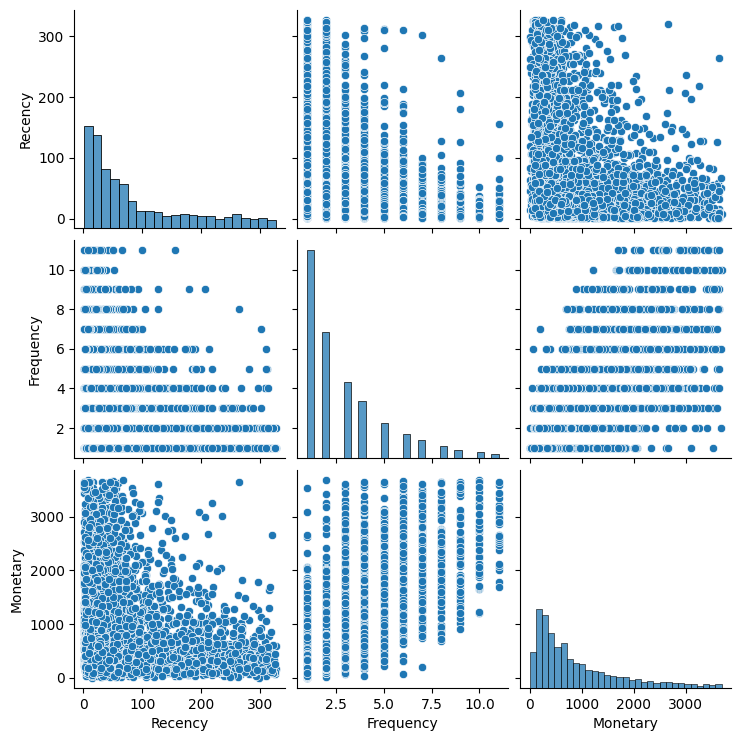

In [217]:
sns.pairplot(rfm_clean)
plt.show()

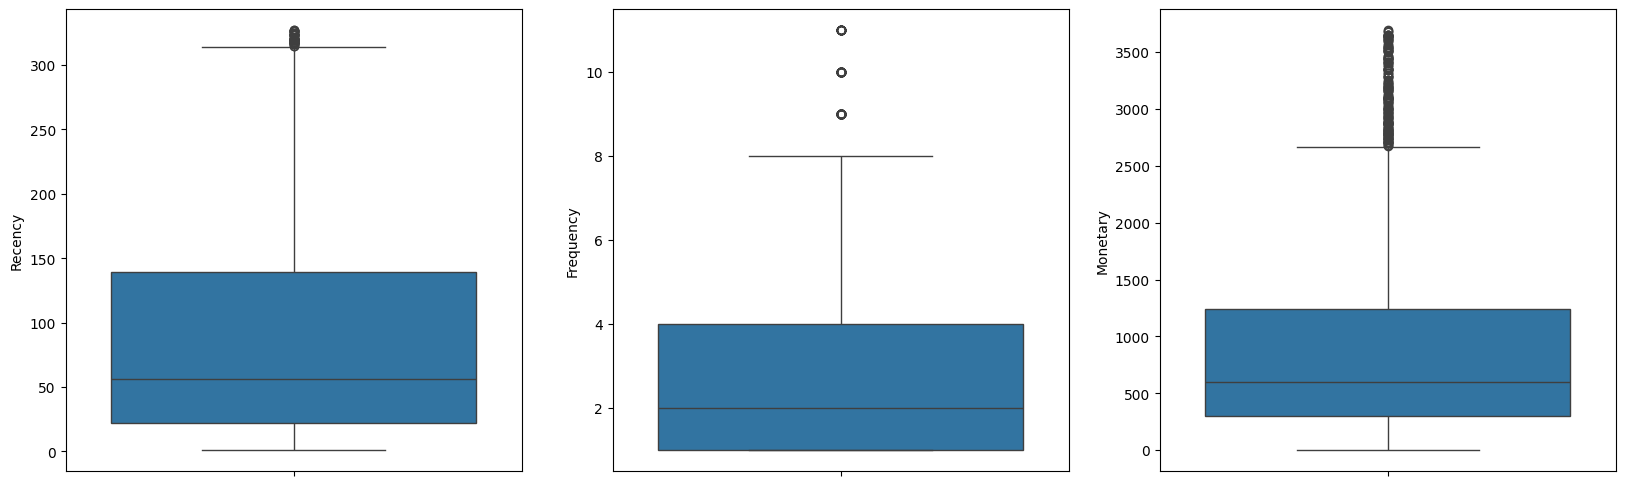

In [218]:
plt.figure(figsize=(20,6))

plt.subplot(1,3,1)
sns.boxplot(y=rfm_clean['Recency'])

plt.subplot(1,3,2)
sns.boxplot(y=rfm_clean['Frequency'])

plt.subplot(1,3,3)
sns.boxplot(y=rfm_clean['Monetary'])

plt.show()

In [219]:
rfm_log = np.log1p(rfm_clean)

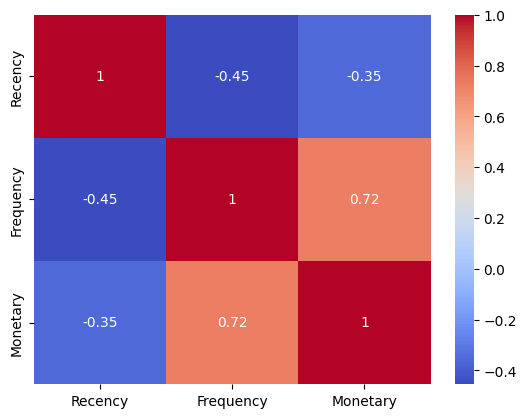

In [220]:
sns.heatmap(rfm_log.corr(), annot=True, cmap="coolwarm")
plt.show()

<Figure size 200x200 with 0 Axes>

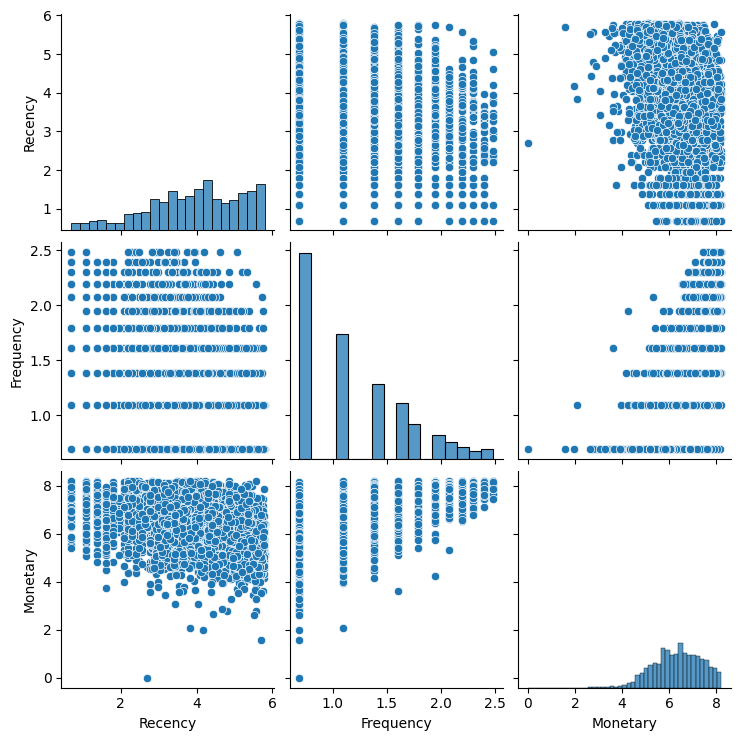

In [221]:
plt.figure(figsize=(2,2))
sns.pairplot(rfm_log)
plt.show()

In [222]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

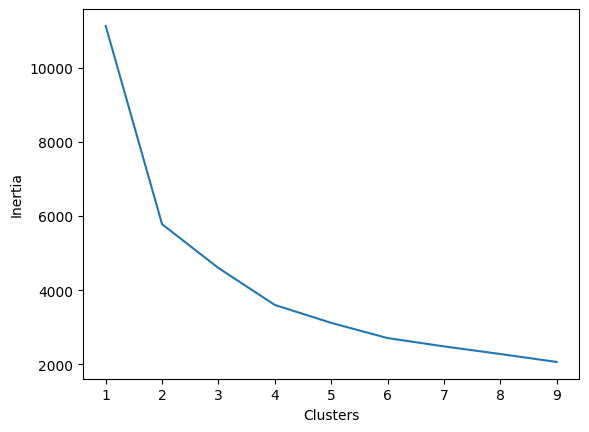

In [225]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.show()

In [226]:
from sklearn.metrics import silhouette_score

for k in range(2,8):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(k, score)

2 0.40740403424528254
3 0.2982791937790884
4 0.3206985853876248
5 0.28008890092207733
6 0.2968767559348015
7 0.2890664855780171


In [227]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(rfm_scaled)
rfm_log["Cluster"] = clusters

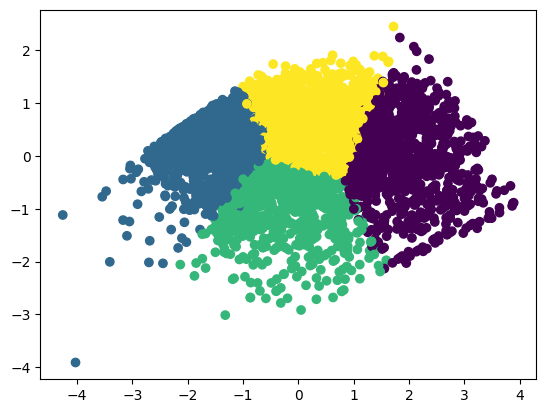

In [228]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(rfm_scaled)

plt.scatter(pca_data[:,0], pca_data[:,1], c=rfm_log["Cluster"])
plt.show()

In [229]:
rfm_log.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,2.718138,1.882259,7.407242
1,5.037751,0.762376,5.393904
2,2.949216,0.939167,5.828559
3,4.455708,1.298785,6.838246


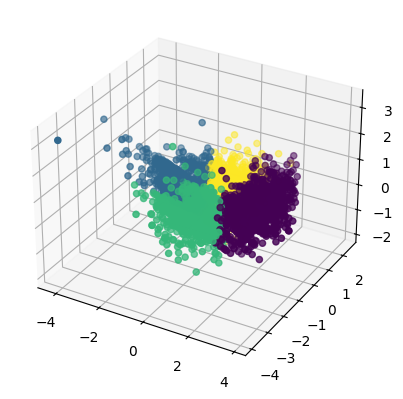

In [230]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
data_3d = pca.fit_transform(rfm_scaled)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(data_3d[:,0], data_3d[:,1], data_3d[:,2],
           c=rfm_log["Cluster"])
plt.show()